In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv('dataset_study.csv')

## Data Exploration

In [3]:
df.head()

,student_id,study_hours,grade
0,1,9.15,91.91
1,2,9.37,86.81
2,3,2.86,53.39
3,4,8.30,85.52
4,5,6.42,77.98


In [4]:
df.shape

(5000, 3)

In [5]:
df.isnull().sum()

student_id     0
study_hours    0
grade          0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   5000 non-null   int64  
 1   study_hours  5000 non-null   float64
 2   grade        5000 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [8]:
df.describe()

,student_id,study_hours,grade
count,5000.000000,5000.000000,5000.000000
mean,2500.500000,5.031654,64.969712
std,1443.520003,2.910579,17.657329
min,1.000000,0.000000,15.520000
25%,1250.750000,2.520000,51.717500
50%,2500.500000,5.050000,64.975000
75%,3750.250000,7.582500,78.710000
max,5000.000000,10.000000,100.000000


In [9]:
def explore_(df, feature_name):
    if df[feature].dtype == 'float64':
        print(f"***********************\n")
        print(f"Feature Name : {feature_name}\n")
        print(f"Value Counts : {df[feature_name].value_counts()}\n")
        print(f"***********************\n")

In [10]:
for feature in df.columns:
    explore_(df, feature)

***********************

Feature Name : study_hours

Value Counts : study_hours
7.24    13
9.45    12
8.42    12
0.28    11
0.37    11
        ..
7.74     1
7.16     1
2.09     1
9.27     1
9.86     1
Name: count, Length: 998, dtype: int64

***********************

***********************

Feature Name : grade

Value Counts : grade
100.00    79
58.75      6
81.88      5
66.19      5
80.72      5
          ..
34.63      1
83.92      1
98.43      1
56.52      1
55.08      1
Name: count, Length: 3452, dtype: int64

***********************



## Visuallization

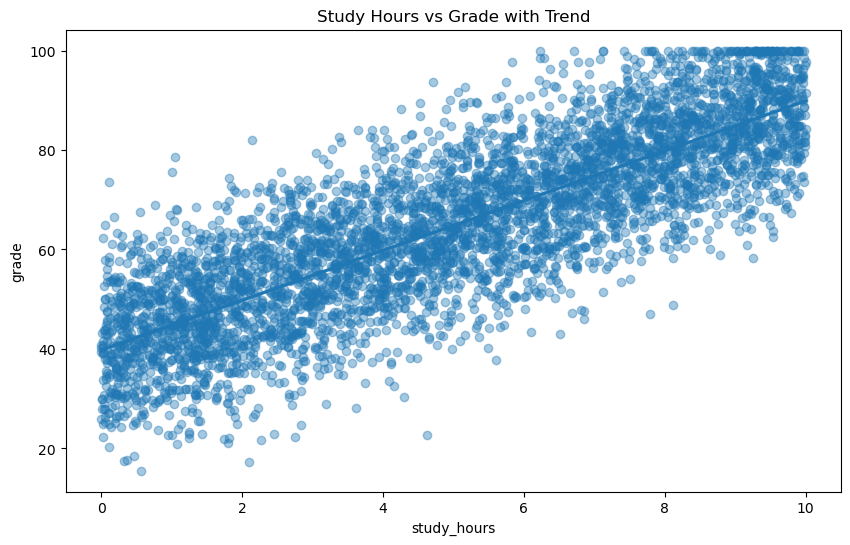

In [11]:
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='study_hours', y='grade', scatter_kws={'alpha':0.4})
plt.title("Study Hours vs Grade with Trend")
plt.show()

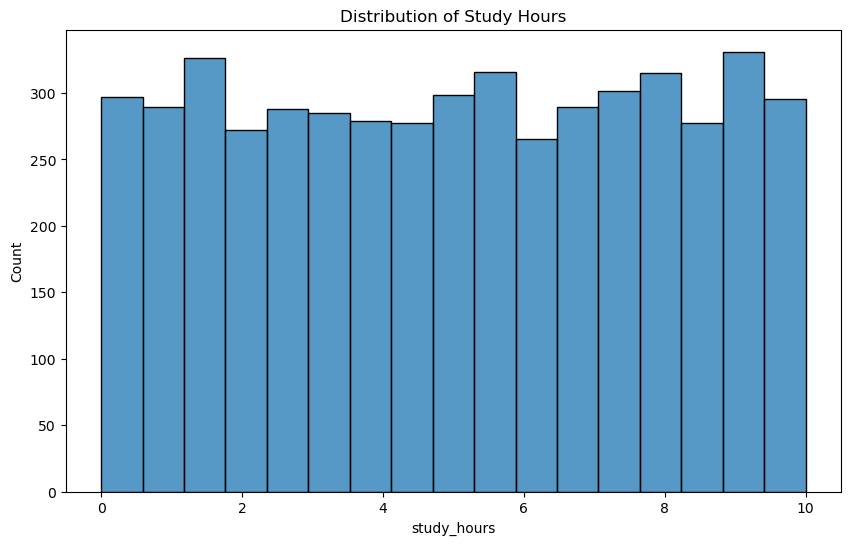

In [12]:
plt.figure(figsize = (10, 6))
sns.histplot(df['study_hours'])
plt.title("Distribution of Study Hours")
plt.show()

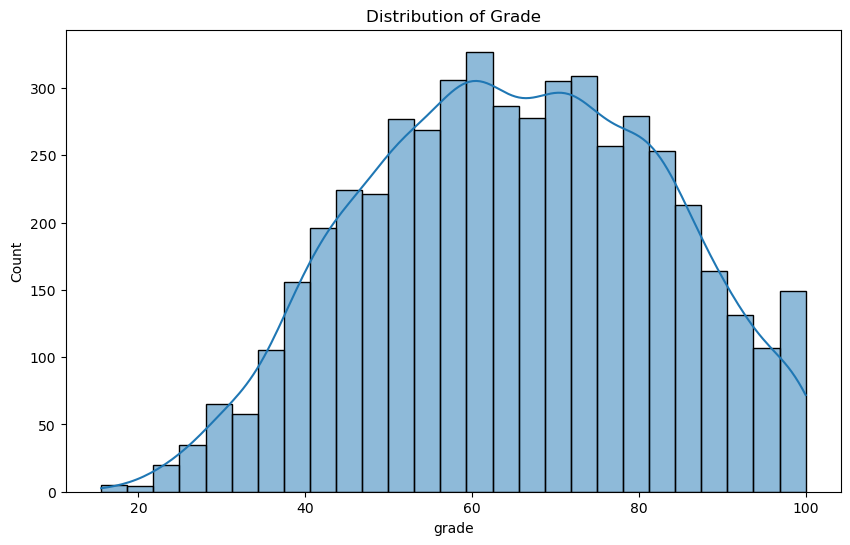

In [13]:
plt.figure(figsize = (10, 6))
sns.histplot(df['grade'], kde=True)
plt.title("Distribution of Grade")
plt.show()

In [14]:
# # Ensure all values are included and label the bins
# df['Hours'] = pd.cut(
#     df['study_hours'],
#     bins=[0,2,4,6,8,10,12, df['study_hours'].max()+1],  # add max+1 to cover all
#     labels=['0-2','2-4','4-6','6-8','8-10','10-12','12+'],
#     include_lowest=True
# )

# plt.figure(figsize=(10,6))
# sns.boxplot(data=df, x='Hours', y='grade')
# plt.title("Grade by Study Hour Ranges")
# plt.xticks(rotation=45)
# plt.show()

In [15]:
df.isnull().sum()

student_id     0
study_hours    0
grade          0
dtype: int64

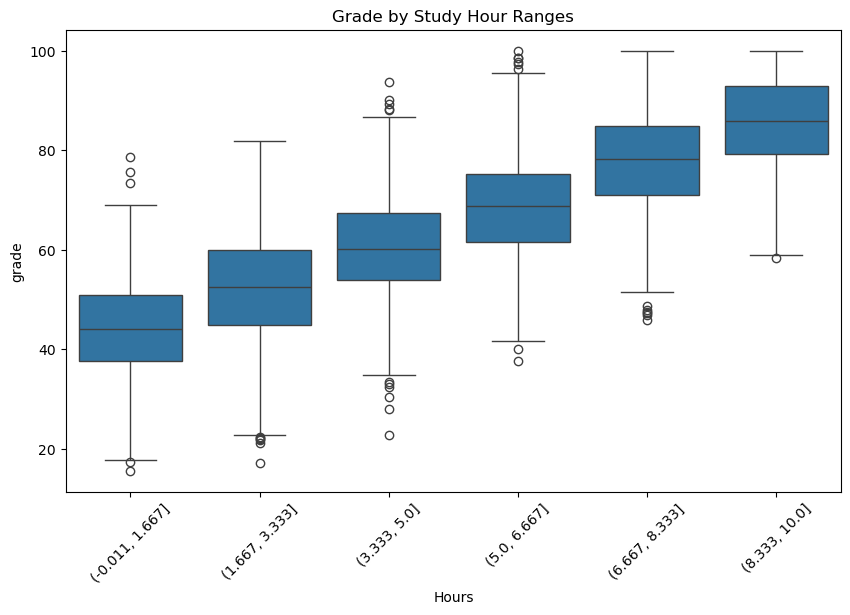

In [16]:
# Create 6 equal-width bins automatically
df['Hours'] = pd.cut(df['study_hours'], bins=6, include_lowest=True)

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Hours', y='grade')
plt.title("Grade by Study Hour Ranges")
plt.xticks(rotation=45)
plt.show()

## Outlier Removal

In [17]:
q1 = df['grade'].quantile(0.25)
q3 = df['grade'].quantile(0.75)

In [18]:
iqr = q3 - q1

In [19]:
lower_bound = q1-1.5*iqr
upper_bound = q3+1.5*iqr

In [20]:
lower_bound

11.228750000000012

In [21]:
upper_bound

119.19874999999999

In [22]:
!pip install feature_engine

In [23]:
from feature_engine.outliers import ArbitraryOutlierCapper

In [24]:
arb = ArbitraryOutlierCapper(min_capping_dict = {'grade': lower_bound},
                             max_capping_dict = {'grade': upper_bound})

In [25]:
df = arb.fit_transform(df)

<Axes: >

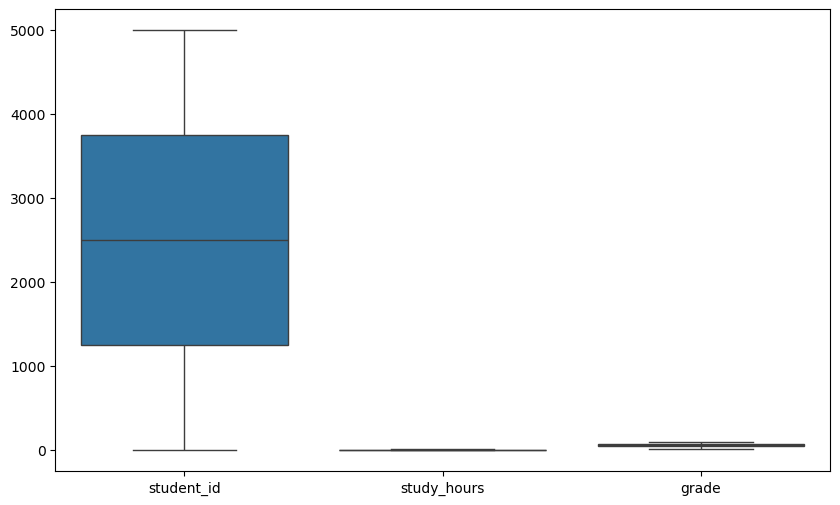

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)

## Remvoe Null Values

In [27]:
# df = df.dropna()
# df['grade'] = df['grade'].fillna(df['grade'].mean())
# df['study_hours'] = df['grade'].fillna(df['study_hours'].mean())

In [28]:
# df.isnull().sum()

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df[['study_hours']])

## Train Test Split

In [30]:
from sklearn.model_selection import train_test_split
x = df[['study_hours']]
y = df['grade']
x_train, x_test, y_train, y_test = train_test_split(x_scaled, df['grade'], test_size=0.2, random_state=42)

## Train Models

In [31]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [32]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

In [33]:
sgd = SGDRegressor(max_iter=50, learning_rate = 'constant', eta0=0.01)
sgd.fit(x_train, y_train)
y_pred1 = sgd.predict(x_test)

In [34]:
ridge = Ridge(alpha=0.01)
ridge.fit(x_train, y_train)
y_pred2 = ridge.predict(x_test)

In [35]:
lasso = Lasso(alpha=0.01)
lasso.fit(x_train, y_train)
y_pred3 = lasso.predict(x_test)

In [36]:
elas_net = ElasticNet(alpha = 0.01, l1_ratio=0.3)
elas_net.fit(x_train, y_train)
y_pred4 = elas_net.predict(x_test)

## Accuracy Score

In [37]:
from sklearn.metrics import r2_score, mean_squared_error

In [38]:
print(f"Linear Regression")
print("R2 Score : ", r2_score(y_test, y_pred))
print("MSE : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print(f"\nStochastic Gradient Descent")
print("R2 Score : ", r2_score(y_test, y_pred1))
print("MSE : ", np.sqrt(mean_squared_error(y_test, y_pred1)))
print(f"\nRidge Regression")
print("R2 Score : ", r2_score(y_test, y_pred2))
print("MSE : ", np.sqrt(mean_squared_error(y_test, y_pred2)))
print(f"\nLasso Regression")
print("R2 Score : ", r2_score(y_test, y_pred3))
print("MSE : ", np.sqrt(mean_squared_error(y_test, y_pred3)))
print(f"\nElasticNet Regression")
print("R2 Score : ", r2_score(y_test, y_pred4))
print("MSE : ", np.sqrt(mean_squared_error(y_test, y_pred4)))

Linear Regression
R2 Score :  0.6788564645776802
MSE :  10.132136291623313

Stochastic Gradient Descent
R2 Score :  0.6715125472070002
MSE :  10.24733239434424

Ridge Regression
R2 Score :  0.67885641956779
MSE :  10.132137001658354

Lasso Regression
R2 Score :  0.6788437787775917
MSE :  10.13233640928407

ElasticNet Regression
R2 Score :  0.6786938009446889
MSE :  10.134702000208526


## Try Model Performance

In [39]:
# Enter Study Hours
study_hours = float(input("Enter your Study Hours : "))

# Scale the Input
scale_study_hours = scaler.transform(pd.DataFrame([[study_hours]], columns=['study_hours']))

# Prdictin Using Trained Model
predicted_grade_lr       =   lr.predict(scale_study_hours)
predicted_grade_ridge    =   ridge.predict(scale_study_hours)
predicted_grade_lasso    =   lasso.predict(scale_study_hours)
predicted_grade_elastic  =   elas_net.predict(scale_study_hours)
predicted_grade_sgd      =   sgd.predict(scale_study_hours)

# Convert grade into % in (0-100)
predicted_grade_lr       =   np.clip(predicted_grade_lr[0], 0, 100)
predicted_grade_ridge    =   np.clip(predicted_grade_ridge[0], 0, 100)
predicted_grade_lasso    =   np.clip(predicted_grade_lasso[0], 0, 100)
predicted_grade_elastic  =   np.clip(predicted_grade_elastic[0], 0, 100)
predicted_grade_sgd      =   np.clip(predicted_grade_sgd[0], 0, 100)

# Show Result
print(f"Predicted Grade for {study_hours}% : ")
print("Linear Regression : ", predicted_grade_lr)
print("Ridge Regression : ", predicted_grade_ridge)
print("Lasso Regression : ", predicted_grade_lasso)
print("ElasticNet Regression : ", predicted_grade_elastic)
print("SGD Regressor : ", predicted_grade_sgd)

Enter your Study Hours :  6


Predicted Grade for 6.0% : 
Linear Regression :  69.91269790290555
Ridge Regression :  69.91268572161447
Lasso Regression :  69.90934884277755
ElasticNet Regression :  69.8778294754771
SGD Regressor :  69.94453553531626
